# Import library

In [1]:
import time
import os
import os
import dagshub
import mlflow
import torch
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO, settings

# Global setting

In [2]:
# ML Flow dan DagsHub Integration
dagshub.init(repo_owner='abiyamf', repo_name='thesis', mlflow=True)
settings.update({"mlflow": True})

Accessing as abiyamf

Initialized MLflow to track repo "abiyamf/thesis"

Repository abiyamf/thesis initialized!

In [3]:
os.environ["MLFLOW_KEEP_RUN_ACTIVE"] = "True"
gpu_name = torch.cuda.get_device_name(0)

def format_duration(seconds: float) -> str:
    """Convert seconds into 'Hh Mm Ss' format."""
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    return f"{hours}h {minutes}m {secs}s"

def save_class_metrics(val_results, mode):
    # Ambil nama class
    names = val_results.names

    # Data per-class
    data = {
        "class": [names[i] for i in range(len(names))],
        "precision": val_results.box.p.tolist(),
        "recall": val_results.box.r.tolist(),
        "mAP50-box": val_results.box.ap50.tolist(),
        "mAP50-95-box": val_results.box.maps.tolist(),
        "mAP50-mask": val_results.seg.ap50.tolist(),
        "mAP50-95-mask": val_results.seg.maps.tolist(),
    }

    # Tambahkan baris agregat "all"
    all_row = {
        "class": "all",
        "precision": float(val_results.box.mp),
        "recall": float(val_results.box.mr),
        "mAP50-box": float(val_results.box.map50),
        "mAP50-95-box": float(val_results.box.map),
        "mAP50-mask": float(val_results.seg.map50),
        "mAP50-95-mask": float(val_results.seg.map),
    }

    for key in data.keys():
        data[key].insert(0, all_row[key])

    # Buat DataFrame dan simpan
    df = pd.DataFrame(data)
    csv_path = os.path.join(str(val_results.save_dir), f"class_metrics_{mode}.csv")
    df.to_csv(csv_path, index=False)

    return csv_path

# Yolo11

## Leaf only

In [4]:
# Variabel Global
projectType = "yolo11_segmentation_leaf_class_only_experiment"
imgsz = 640
models = ['yolo11n-seg.pt','yolo11s-seg.pt','yolo11m-seg.pt']
sizes = ['nano','small','medium']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../dataset_collection/roboflow/segmentation/segmentation_mask_leaf"
project_base_objectDetection_all_class = "results/yolo_v11/segmentation_leaf_class_only"

In [5]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50-box": float(validation.box.map50),
            "val mAP50-95-box": float(validation.box.map),
            "val mAP50-mask": float(validation.seg.map50),
            "val mAP50-95-mask": float(validation.seg.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

2025/12/21 14:09:46 INFO mlflow.tracking.fluent: Experiment with name 'thesis-yolo11_segmentation_leaf_class_only_experiment' does not exist. Creating a new experiment.


New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/segmentation/segmentation_mask_leaf/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosa

2025/12/21 14:10:41 INFO mlflow.tracking.fluent: Experiment with name 'results/yolo_v11/segmentation_leaf_class_only/training' does not exist. Creating a new experiment.


MLflow: logging run_id(b54c74338bb74a27860ca5a462cca6a1) to https://dagshub.com/abiyamf/thesis.mlflow
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\abiyamf\Documents\Code Program\Thesis\normal_segmentation_experiment\results\yolo_v11\segmentation_leaf_class_only\training\nano
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size
      1/100      2.99G     0.6813      1.818      2.813      1.147         62        640: 100% ━━━━━━━━━━━━ 33/33 2.7it/s 12.3s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.6s0.8s
                   all         75        132     0.0058      0.985      0.382      0.297    0.00567      0.971      0.378      0.324

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  

## Lession only

In [6]:
# Variabel Global
projectType = "yolo11_segmentation_lession_class_only_experiment"
imgsz = 640
models = ['yolo11n-seg.pt','yolo11s-seg.pt','yolo11m-seg.pt']
sizes = ['nano','small','medium']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../dataset_collection/roboflow/segmentation/segmentation_mask_lession"
project_base_objectDetection_all_class = "results/yolo_v11/segmentation_lession_class_only"

In [7]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50-box": float(validation.box.map50),
            "val mAP50-95-box": float(validation.box.map),
            "val mAP50-mask": float(validation.seg.map50),
            "val mAP50-95-mask": float(validation.seg.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

2025/12/21 15:01:22 INFO mlflow.tracking.fluent: Experiment with name 'thesis-yolo11_segmentation_lession_class_only_experiment' does not exist. Creating a new experiment.


New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/segmentation/segmentation_mask_lession/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, m

2025/12/21 15:02:07 INFO mlflow.tracking.fluent: Experiment with name 'results/yolo_v11/segmentation_lession_class_only/training' does not exist. Creating a new experiment.


MLflow: logging run_id(05650853e5e841509c9e4d6d14acea1d) to https://dagshub.com/abiyamf/thesis.mlflow
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\abiyamf\Documents\Code Program\Thesis\normal_segmentation_experiment\results\yolo_v11\segmentation_lession_class_only\training\nano
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size
      1/100       5.6G      1.413      1.477      3.441     0.8852        155        640: 100% ━━━━━━━━━━━━ 33/33 3.2it/s 10.3s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 4.9it/s 0.6s0.4s
                   all         75        277    0.00283      0.225     0.0297      0.013    0.00695       0.54     0.0413     0.0265

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_los

## Leaf and Lession

In [8]:
# Variabel Global
projectType = "yolo11_segmentation_leaf_and_lession_experiment"
imgsz = 640
models = ['yolo11n-seg.pt','yolo11s-seg.pt','yolo11m-seg.pt']
sizes = ['nano','small','medium']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession"
project_base_objectDetection_all_class = "results/yolo_v11/segmentation_leaf_and_lession"

In [9]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50-box": float(validation.box.map50),
            "val mAP50-95-box": float(validation.box.map),
            "val mAP50-mask": float(validation.seg.map50),
            "val mAP50-95-mask": float(validation.seg.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

2025/12/21 15:51:23 INFO mlflow.tracking.fluent: Experiment with name 'thesis-yolo11_segmentation_leaf_and_lession_experiment' does not exist. Creating a new experiment.


New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum

2025/12/21 15:52:08 INFO mlflow.tracking.fluent: Experiment with name 'results/yolo_v11/segmentation_leaf_and_lession/training' does not exist. Creating a new experiment.


MLflow: logging run_id(0c29b65464724d7b99d1bd37a405acad) to https://dagshub.com/abiyamf/thesis.mlflow
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\abiyamf\Documents\Code Program\Thesis\normal_segmentation_experiment\results\yolo_v11\segmentation_leaf_and_lession\training\nano
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size
      1/100      5.62G     0.8626      1.807      3.341      1.065        217        640: 100% ━━━━━━━━━━━━ 33/33 3.1it/s 10.5s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 4.2it/s 0.7s0.6s
                   all         75        409     0.0135      0.583      0.204      0.166      0.013      0.574      0.203      0.184

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss 

# Yolo12

## Leaf only

In [10]:
# Variabel Global
projectType = "yolo12_segmentation_leaf_class_only_experiment"
imgsz = 640
models = ['yolo12n-seg.yaml','yolo12s-seg.yaml','yolo12m-seg.yaml']
sizes = ['nano','small','medium']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../dataset_collection/roboflow/segmentation/segmentation_mask_leaf"
project_base_objectDetection_all_class = "results/yolo_v12/segmentation_leaf_class_only"

In [11]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50-box": float(validation.box.map50),
            "val mAP50-95-box": float(validation.box.map),
            "val mAP50-mask": float(validation.seg.map50),
            "val mAP50-95-mask": float(validation.seg.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

2025/12/21 16:41:52 INFO mlflow.tracking.fluent: Experiment with name 'thesis-yolo12_segmentation_leaf_class_only_experiment' does not exist. Creating a new experiment.


New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/segmentation/segmentation_mask_leaf/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n-seg.yaml, momentum=0.937, mo

2025/12/21 16:42:36 INFO mlflow.tracking.fluent: Experiment with name 'results/yolo_v12/segmentation_leaf_class_only/training' does not exist. Creating a new experiment.


MLflow: logging run_id(f4034ee2407e47df99c8dda0e7fcb332) to https://dagshub.com/abiyamf/thesis.mlflow
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\abiyamf\Documents\Code Program\Thesis\normal_segmentation_experiment\results\yolo_v12\segmentation_leaf_class_only\training\nano
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size
      1/100      5.58G      3.185      7.943      4.036      4.241         62        640: 100% ━━━━━━━━━━━━ 33/33 3.0it/s 10.9s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 4.2it/s 0.7s0.6s
                   all         75        132    0.00344      0.495    0.00319   0.000941   0.000381      0.167    0.00034   8.98e-05

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  

## Lession only

In [12]:
# Variabel Global
projectType = "yolo12_segmentation_lession_class_only_experiment"
imgsz = 640
models = ['yolo12n-seg.yaml','yolo12s-seg.yaml','yolo12m-seg.yaml']
sizes = ['nano','small','medium']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../dataset_collection/roboflow/segmentation/segmentation_mask_lession"
project_base_objectDetection_all_class = "results/yolo_v12/segmentation_lession_class_only"

In [13]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50-box": float(validation.box.map50),
            "val mAP50-95-box": float(validation.box.map),
            "val mAP50-mask": float(validation.seg.map50),
            "val mAP50-95-mask": float(validation.seg.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

2025/12/21 17:41:29 INFO mlflow.tracking.fluent: Experiment with name 'thesis-yolo12_segmentation_lession_class_only_experiment' does not exist. Creating a new experiment.


New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/segmentation/segmentation_mask_lession/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n-seg.yaml, momentum=0.937,

2025/12/21 17:42:14 INFO mlflow.tracking.fluent: Experiment with name 'results/yolo_v12/segmentation_lession_class_only/training' does not exist. Creating a new experiment.


MLflow: logging run_id(4ca5133bf93e4483b8432ca3ea3359be) to https://dagshub.com/abiyamf/thesis.mlflow
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\abiyamf\Documents\Code Program\Thesis\normal_segmentation_experiment\results\yolo_v12\segmentation_lession_class_only\training\nano
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size
      1/100      5.64G       5.38      20.18      27.95      4.773        155        640: 100% ━━━━━━━━━━━━ 33/33 2.9it/s 11.2s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 5.2it/s 0.6s0.4s
                   all         75        277          0          0          0          0          0          0          0          0

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_los

## Leaf and Lession

In [14]:
# Variabel Global
projectType = "yolo12_segmentation_leaf_and_lession_experiment"
imgsz = 640
models = ['yolo12n-seg.yaml','yolo12s-seg.yaml','yolo12m-seg.yaml']
sizes = ['nano','small','medium']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession"
project_base_objectDetection_all_class = "results/yolo_v12/segmentation_leaf_and_lession"

In [15]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50-box": float(validation.box.map50),
            "val mAP50-95-box": float(validation.box.map),
            "val mAP50-mask": float(validation.seg.map50),
            "val mAP50-95-mask": float(validation.seg.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

2025/12/21 18:39:51 INFO mlflow.tracking.fluent: Experiment with name 'thesis-yolo12_segmentation_leaf_and_lession_experiment' does not exist. Creating a new experiment.


New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n-seg.yaml, moment

2025/12/21 18:40:40 INFO mlflow.tracking.fluent: Experiment with name 'results/yolo_v12/segmentation_leaf_and_lession/training' does not exist. Creating a new experiment.


MLflow: logging run_id(05996924b799483dbe28f605944b582d) to https://dagshub.com/abiyamf/thesis.mlflow
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\abiyamf\Documents\Code Program\Thesis\normal_segmentation_experiment\results\yolo_v12\segmentation_leaf_and_lession\training\nano
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size
      1/100      5.55G      3.233      11.44      4.314      4.257        217        640: 100% ━━━━━━━━━━━━ 33/33 2.5it/s 13.1s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 4.2it/s 0.7s0.6s
                   all         75        409    0.00253       0.25    0.00214   0.000612    0.00223      0.204    0.00163   0.000503

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss 

# Size Comparison

## Leaf only

In [ ]:
# Variabel Global
projectType = "yolo11_segmentation_leaf_class_only_imgsz_experiment"
imgsz = 1024
models = ['yolo11n-seg.pt']
sizes = ['nano']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../dataset_collection/roboflow/segmentation/segmentation_mask_leaf"
project_base_objectDetection_all_class = "results/yolo_v11/segmentation_leaf_class_only_imgsz"

In [5]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50-box": float(validation.box.map50),
            "val mAP50-95-box": float(validation.box.map),
            "val mAP50-mask": float(validation.seg.map50),
            "val mAP50-95-mask": float(validation.seg.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/segmentation/segmentation_mask_leaf/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mos

AcceleratorError: Caught AcceleratorError in pin memory thread for device 0.
Original Traceback (most recent call last):
  File "c:\Users\abiyamf\anaconda3\envs\thesis\Lib\site-packages\torch\utils\data\_utils\pin_memory.py", line 34, in do_one_step
    data = pin_memory(data, device)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\abiyamf\anaconda3\envs\thesis\Lib\site-packages\torch\utils\data\_utils\pin_memory.py", line 68, in pin_memory
    {k: pin_memory(sample, device) for k, sample in data.items()}
        ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\abiyamf\anaconda3\envs\thesis\Lib\site-packages\torch\utils\data\_utils\pin_memory.py", line 57, in pin_memory
    return data.pin_memory(device)
           ^^^^^^^^^^^^^^^^^^^^^^^
torch.AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other

## Lession only

In [4]:
# Variabel Global
projectType = "yolo11_segmentation_lession_class_only_imgsz_experiment"
imgsz = 1024
models = ['yolo11n-seg.pt']
sizes = ['nano']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../dataset_collection/roboflow/segmentation/segmentation_mask_lession"
project_base_objectDetection_all_class = "results/yolo_v11/segmentation_lession_class_only_imgsz"

In [5]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50-box": float(validation.box.map50),
            "val mAP50-95-box": float(validation.box.map),
            "val mAP50-mask": float(validation.seg.map50),
            "val mAP50-95-mask": float(validation.seg.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/segmentation/segmentation_mask_lession/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, 

## Leaf and Lession

In [4]:
# Variabel Global
projectType = "yolo11_segmentation_leaf_and_lession_imgsz_experiment"
imgsz = 1024
models = ['yolo11n-seg.pt']
sizes = ['nano']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession"
project_base_objectDetection_all_class = "results/yolo_v11/segmentation_leaf_and_lession_imgsz"

In [5]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50-box": float(validation.box.map50),
            "val mAP50-95-box": float(validation.box.map),
            "val mAP50-mask": float(validation.seg.map50),
            "val mAP50-95-mask": float(validation.seg.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

New https://pypi.org/project/ultralytics/8.3.240 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.231  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentu

# Graph comparison

## Yolo11

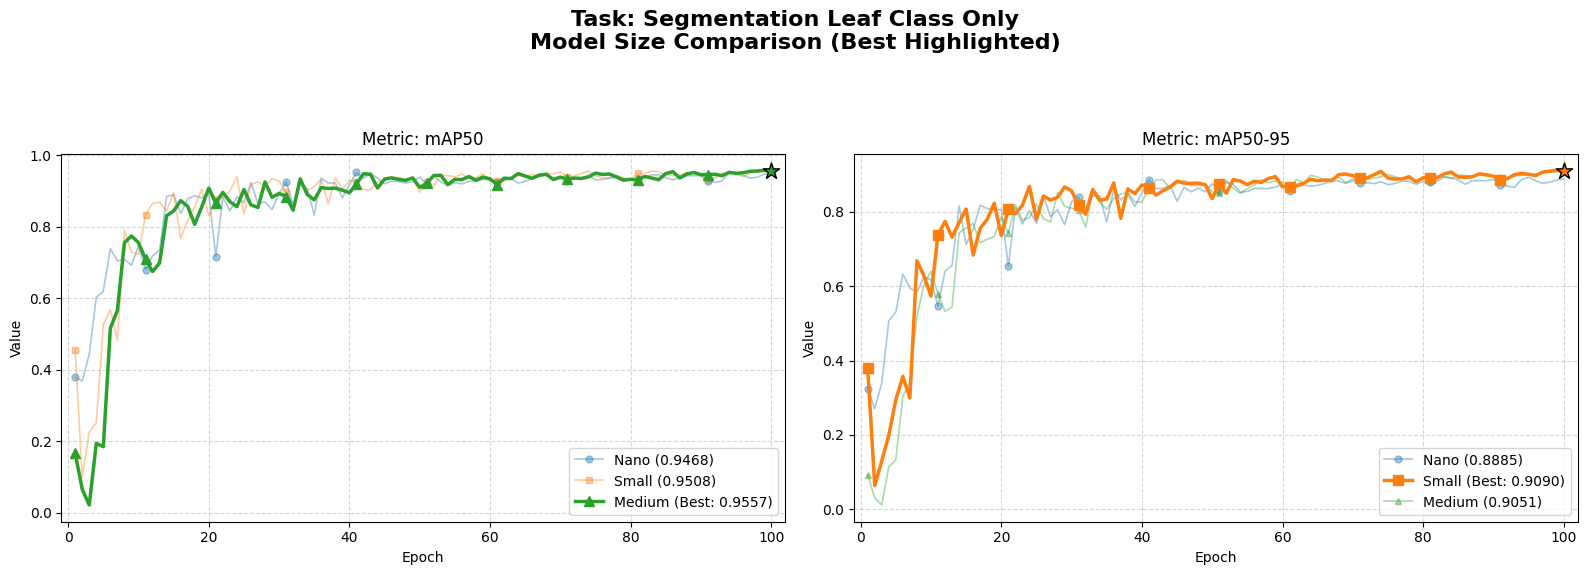

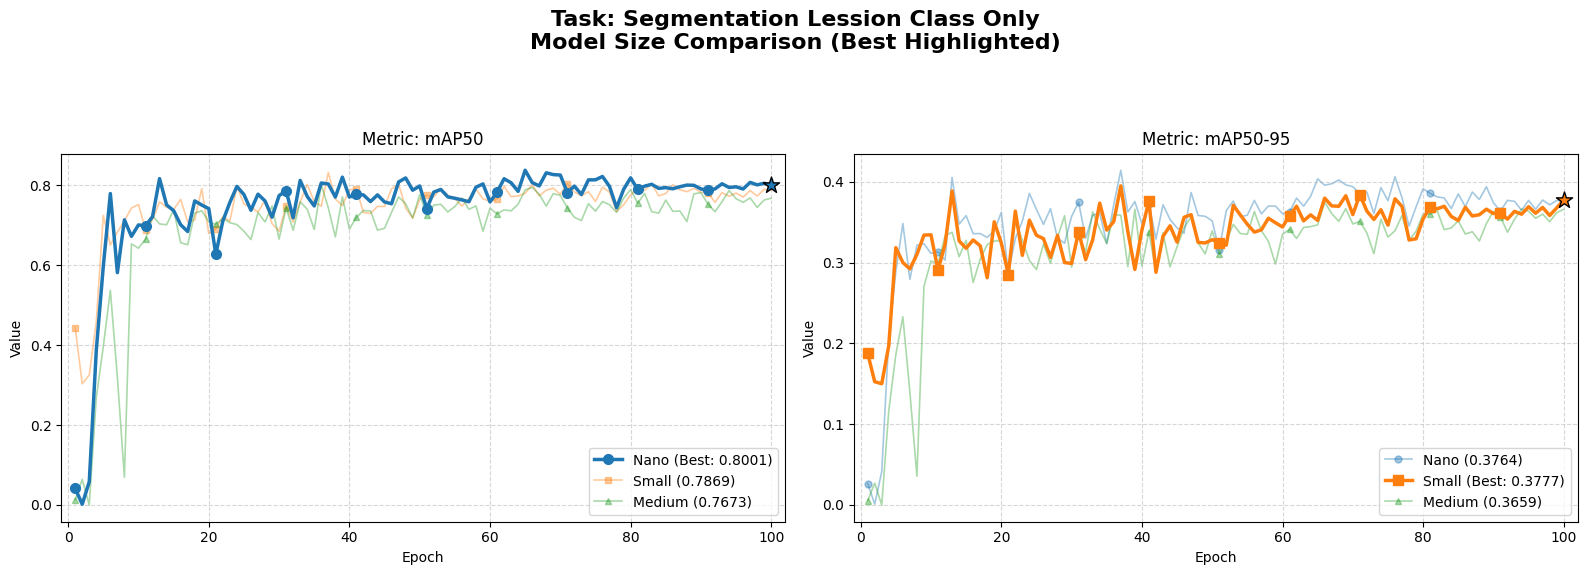

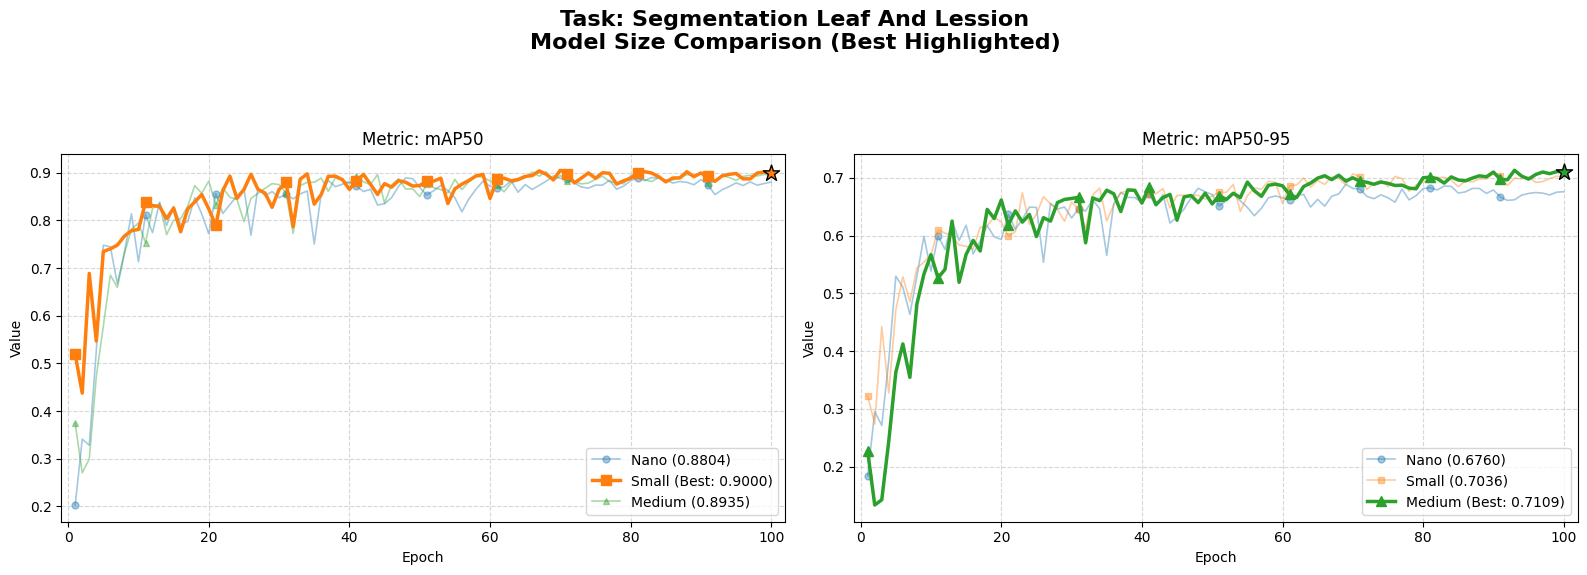

In [7]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. KONFIGURASI ---
base = Path("results")
# Array berisi 3 path version yang berbeda
version_list = [
    "yolo_v11/segmentation_leaf_class_only",
    "yolo_v11/segmentation_lession_class_only",
    "yolo_v11/segmentation_leaf_and_lession"
]
sizes = ["nano", "small", "medium"]

# Map Metrik
metric_map = {
    "mAP50": "metrics/mAP50(M)",
    "mAP50-95": "metrics/mAP50-95(M)",
}

# Style Config
styles = {
    "nano":   {"color": "#1f77b4", "marker": "o", "label": "Nano"},   # Blue / Circle
    "small":  {"color": "#ff7f0e", "marker": "s", "label": "Small"},  # Orange / Square
    "medium": {"color": "#2ca02c", "marker": "^", "label": "Medium"}, # Green / Triangle Up
}

# --- 2. LOOPING PER VERSION (MEMBUAT 3 PLOT BERBEDA) ---
for v_path in version_list:
    
    # Format Judul agar rapi (menghilangkan underscore dan path folder)
    # Contoh: "yolo_v11/segmentation_leaf_class_only" -> "Segmentation Leaf Class Only"
    title_text = v_path.split("/")[-1].replace("_", " ").title()
    
    # Buat Figure Baru untuk setiap Version
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Task: {title_text}\nModel Size Comparison (Best Highlighted)", fontsize=16, fontweight='bold')

    # Loop Metrik (Subplot Kiri & Kanan)
    for idx, (metric_label, metric_col) in enumerate(metric_map.items()):
        ax = axes[idx]
        
        loaded_data = [] 

        # --- 3. LOAD DATA PER SIZE ---
        for size in sizes:
            # Construct path dinamis berdasarkan loop version saat ini
            csv_path = base / v_path / "training" / size / "results.csv"
            
            if not csv_path.exists():
                print(f"[SKIP] Missing: {csv_path}")
                continue
                
            try:
                df = pd.read_csv(csv_path)
                df.columns = [c.strip() for c in df.columns] 
                
                if metric_col not in df.columns:
                    print(f"[WARN] Metric {metric_col} not found in {size}")
                    continue

                loaded_data.append({
                    "size": size,
                    "epochs": df["epoch"],
                    "values": df[metric_col],
                    "final_value": df[metric_col].iloc[-1]
                })
                
            except Exception as e:
                print(f"[ERR] Error processing {csv_path}: {e}")

        if not loaded_data:
            continue

        # --- 4. CARI BEST MODEL ---
        best_model_data = max(loaded_data, key=lambda x: x['final_value'])
        best_size_name = best_model_data['size']

        # --- 5. PLOTTING ---
        for data in loaded_data:
            size = data['size']
            style = styles.get(size, {"color": "gray", "marker": ".", "label": size})
            
            is_best = (size == best_size_name)
            
            # Style Logic
            if is_best:
                alpha = 1.0
                linewidth = 2.5
                zorder = 10
                label_text = f"{style['label']} (Best: {data['final_value']:.4f})"
            else:
                alpha = 0.4
                linewidth = 1.2
                zorder = 1
                label_text = f"{style['label']} ({data['final_value']:.4f})"

            # Plot Garis
            ax.plot(
                data['epochs'],
                data['values'],
                label=label_text,
                color=style['color'],
                linewidth=linewidth,
                alpha=alpha,
                zorder=zorder,
                marker=style['marker'],
                markevery=max(1, len(data['epochs']) // 10),
                markersize=7 if is_best else 5
            )

            # Highlight Endpoint Pemenang
            if is_best:
                ax.scatter(
                    data['epochs'].iloc[-1], 
                    data['final_value'], 
                    color=style['color'], 
                    s=150, 
                    edgecolor='black', 
                    zorder=11,
                    marker='*'
                )

        # Estetika Subplot
        ax.set_title(f"Metric: {metric_label}", fontsize=12)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Value")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc="best", fontsize=10)
        ax.margins(x=0.02)

    plt.tight_layout(rect=[0, 0.03, 1, 0.90]) # Adjust layout agar title tidak tertabrak
    plt.show() # Tampilkan plot, lalu lanjut ke loop version berikutnya

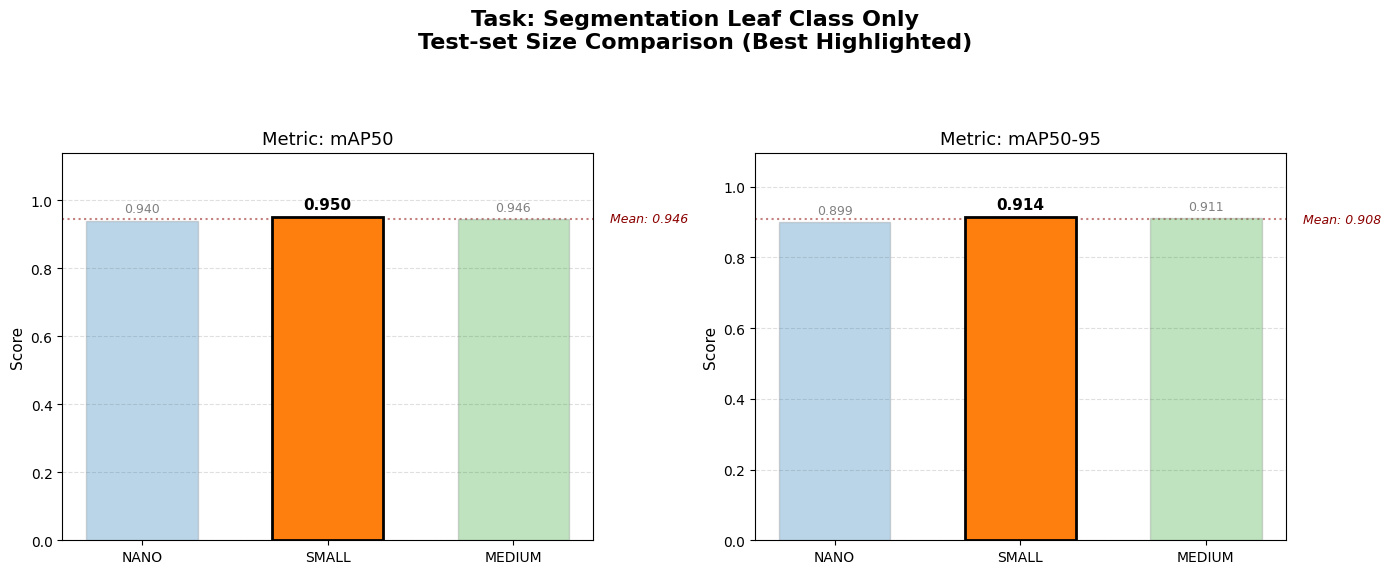

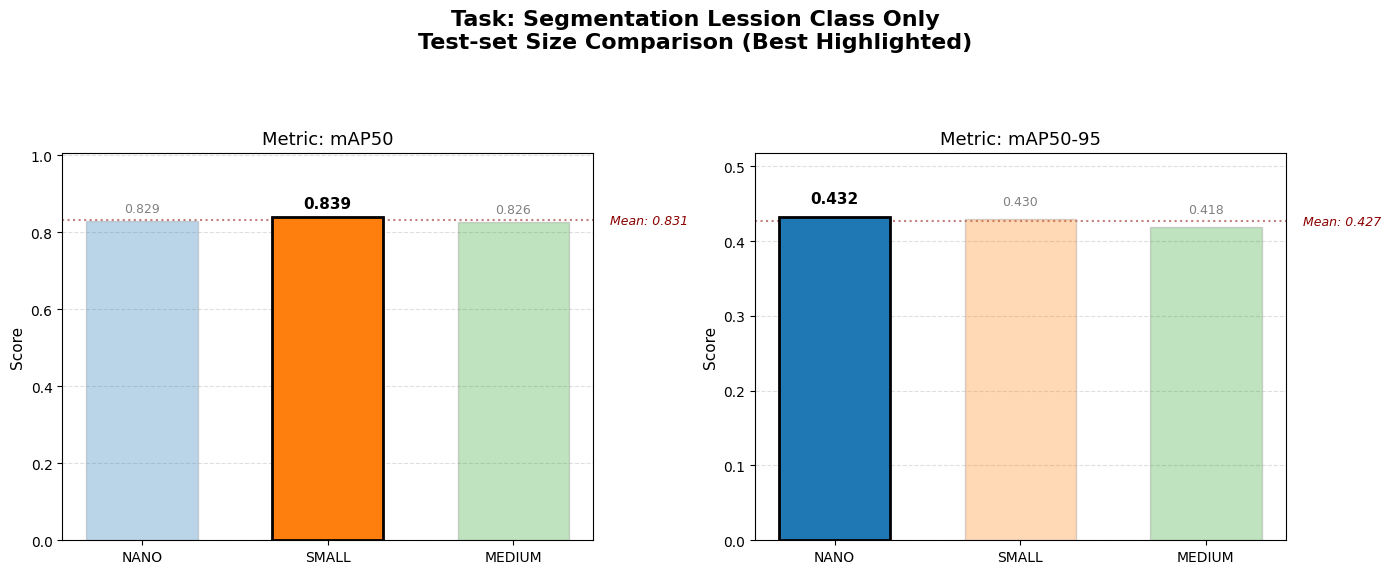

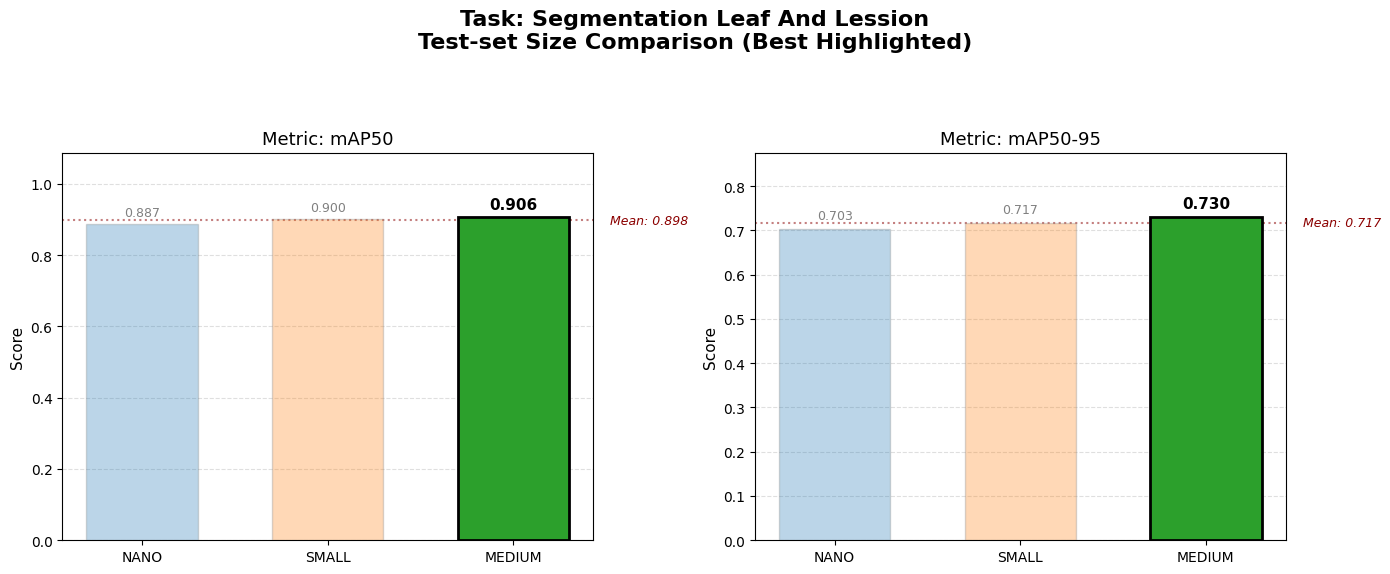

In [8]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. KONFIGURASI ---
base = Path("results")
version_list = [
    "yolo_v11/segmentation_leaf_class_only",
    "yolo_v11/segmentation_lession_class_only",
    "yolo_v11/segmentation_leaf_and_lession"
]
variants = ["nano", "small", "medium"]

# Palet warna konsisten
colors = {
    "nano":   "#1f77b4", # Blue
    "small":  "#ff7f0e", # Orange
    "medium": "#2ca02c", # Green
}

def load_all_row(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    row = df[df["class"] == "all"]
    if row.empty:
        raise ValueError(f"Missing Class == 'all' in {csv_path}")
    return row.iloc[0]

# --- 2. LOOPING PER TASK/VERSION ---
for v_path in version_list:
    
    # Generate Title yang rapi dari path
    # "yolo_v11/segmentation_leaf_class_only" -> "Segmentation Leaf Class Only"
    task_name = v_path.split("/")[-1].replace("_", " ").title()

    # --- A. PERSIAPAN DATA PER TASK ---
    results_data = [] # Reset list untuk setiap version
    
    for variant in variants:
        # Perhatikan: menggunakan v_path (bukan version list)
        csv_path = base / v_path / "validation" / variant / "class_metrics_validation.csv"
        
        row_data = {"variant": variant}
        if not csv_path.exists():
            print(f"[SKIP] Missing: {csv_path}")
            row_data["mAP50"] = np.nan
            row_data["mAP50-95"] = np.nan
        else:
            try:
                r = load_all_row(csv_path)
                # Mapping nama kolom spesifik Segmentation (mask) ke nama umum
                row_data["mAP50"] = float(r["mAP50-mask"])
                row_data["mAP50-95"] = float(r["mAP50-95-mask"])
            except Exception as e:
                print(f"[ERR] Error reading {csv_path}: {e}")
                row_data["mAP50"] = np.nan
                row_data["mAP50-95"] = np.nan
                
        results_data.append(row_data)

    df = pd.DataFrame(results_data)

    # Jika DataFrame kosong atau semua NaN, skip plotting
    if df[["mAP50", "mAP50-95"]].isna().all().all():
        print(f"[WARN] No valid data for {task_name}, skipping plot.")
        continue

    # --- B. VISUALISASI ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Task: {task_name}\nTest-set Size Comparison (Best Highlighted)", fontsize=16, fontweight='bold')

    metrics = ["mAP50", "mAP50-95"]
    x = np.arange(len(variants))
    bar_w = 0.6 

    for ax, metric in zip(axes, metrics):
        # Cari nilai maksimum local untuk chart ini
        max_val = df[metric].max()
        
        # Loop manual per bar
        for i, row in df.iterrows():
            variant = row['variant']
            val = row[metric]
            
            if pd.isna(val): continue

            # Logic: Winner takes all highlighting
            is_best = np.isclose(val, max_val)
            
            # Style Definition
            if is_best:
                alpha = 1.0
                linewidth = 2.0
                edgecolor = 'black'
                zorder = 5
            else:
                alpha = 0.3 # Pudar
                linewidth = 1.0
                edgecolor = 'gray'
                zorder = 3

            # Plot Bar
            bar = ax.bar(
                variant.upper(), 
                val, 
                color=colors.get(variant, "gray"),
                edgecolor=edgecolor,
                linewidth=linewidth,
                alpha=alpha,
                width=bar_w,
                zorder=zorder
            )
            
            # Annotasi Text
            ax.text(
                bar[0].get_x() + bar[0].get_width()/2., 
                val + 0.015,
                f'{val:.3f}',
                ha='center', 
                va='bottom', 
                fontsize=11 if is_best else 9,
                fontweight='bold' if is_best else 'normal',
                color='black' if is_best else 'gray'
            )

        # Estetika Grafik
        ax.set_title(f"Metric: {metric}", fontsize=13)
        ax.set_ylabel("Score", fontsize=11)
        
        # Atur batas Y
        # Menggunakan max_val lokal agar skala grafik proporsional
        if pd.notna(max_val):
            ax.set_ylim(0, max_val * 1.2)
        
        ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

        # Garis Rata-rata
        mean_val = df[metric].mean()
        if pd.notna(mean_val):
            ax.axhline(mean_val, color='darkred', linestyle=':', alpha=0.5, zorder=1)
            ax.text(len(variants)-0.5, mean_val, f' Mean: {mean_val:.3f}', 
                    va='center', fontsize=9, color='darkred', style='italic')

    plt.tight_layout(rect=[0, 0.03, 1, 0.90])
    plt.show() # Tampilkan plot sebelum lanjut ke task berikutnya

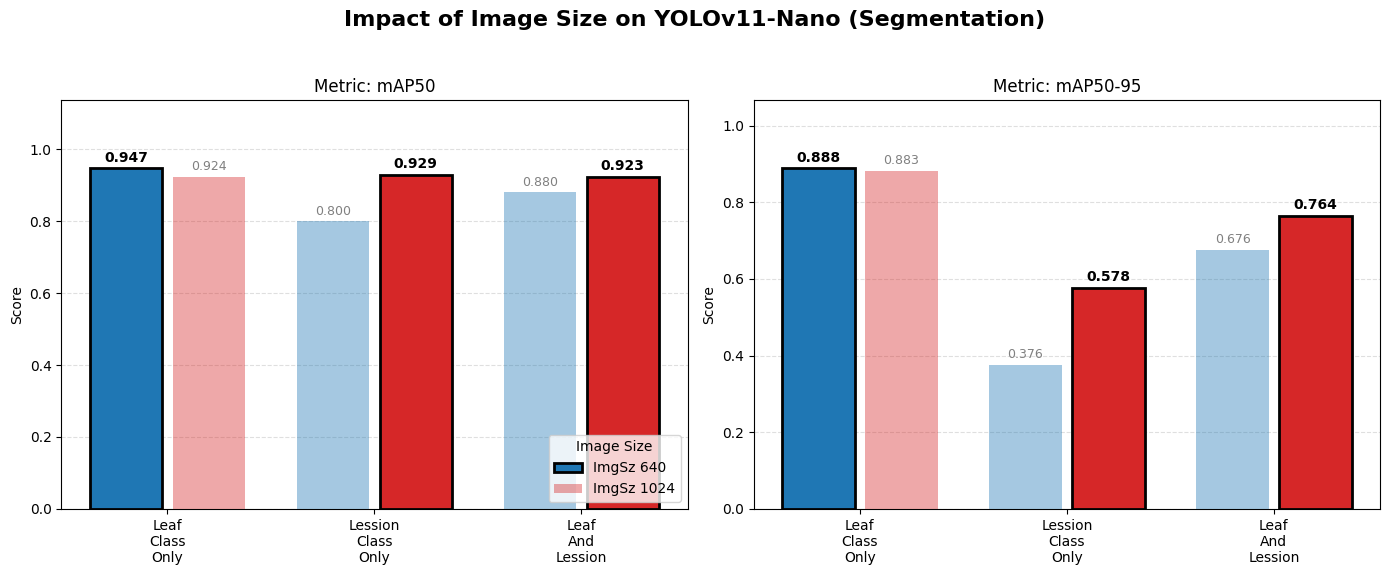

In [11]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. KONFIGURASI ---
base = Path("results")
model_size = "nano" 

# List Task (Akan menjadi label sumbu X)
tasks = [
    "segmentation_leaf_class_only",
    "segmentation_lession_class_only",
    "segmentation_leaf_and_lession"
]

# Konfigurasi Perbandingan
configs = [
    {"label": "ImgSz 640",  "suffix": "",       "color": "#1f77b4"}, # Biru
    {"label": "ImgSz 1024", "suffix": "_imgsz", "color": "#d62728"}, # Merah
]

# Map Metrik Segmentation (Header CSV Ultralytics)
metric_map = {
    "mAP50": "metrics/mAP50(M)",
    "mAP50-95": "metrics/mAP50-95(M)",
}

# --- 2. LOAD DATA KE DATAFRAME ---
# Kita kumpulkan semua data dulu ke satu tabel besar agar mudah di-plot
all_data = []

for task in tasks:
    for conf in configs:
        # Logic Path: Normal vs _imgsz
        folder_name = f"yolo_v11/{task}{conf['suffix']}"
        csv_path = base / folder_name / "training" / model_size / "results.csv"
        
        entry = {
            "task": task,
            "config": conf["label"],
            "mAP50": np.nan,
            "mAP50-95": np.nan
        }
        
        if csv_path.exists():
            try:
                df = pd.read_csv(csv_path)
                df.columns = [c.strip() for c in df.columns]
                
                # Ambil nilai epoch terakhir (final result)
                for key, col in metric_map.items():
                    if col in df.columns:
                        entry[key] = df[col].iloc[-1]
            except Exception as e:
                print(f"[ERR] Error reading {csv_path}: {e}")
        else:
            print(f"[SKIP] Missing: {csv_path}")
            
        all_data.append(entry)

df = pd.DataFrame(all_data)

# --- 3. VISUALISASI GROUPED BAR CHART ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Impact of Image Size on YOLOv11-Nano (Segmentation)", fontsize=16, fontweight='bold')

# Setup Sumbu X
x = np.arange(len(tasks))
width = 0.35  # Lebar tiap bar

metrics_list = ["mAP50", "mAP50-95"]

for ax, metric in zip(axes, metrics_list):
    
    # Loop per Task (index 0, 1, 2) untuk membandingkan 640 vs 1024 di task tersebut
    for i, task in enumerate(tasks):
        
        # Ambil nilai untuk Task ini
        val_640 = df[(df["task"] == task) & (df["config"] == "ImgSz 640")][metric].values[0]
        val_1024 = df[(df["task"] == task) & (df["config"] == "ImgSz 1024")][metric].values[0]
        
        vals = [val_640, val_1024]
        
        # Cari nilai tertinggi (handle NaN jika file tidak ada)
        valid_vals = [v for v in vals if pd.notna(v)]
        max_val = max(valid_vals) if valid_vals else -1
        
        # Plot Dua Bar (Kiri: 640, Kanan: 1024)
        for j, (val, conf) in enumerate(zip(vals, configs)):
            
            # Posisi Bar
            # j=0 -> geser kiri (-width/2)
            # j=1 -> geser kanan (+width/2)
            position = x[i] + (j - 0.5) * (width + 0.05) 
            
            if pd.isna(val): continue

            # Logic Highlight: Winner gets solid color
            is_best = np.isclose(val, max_val)
            
            alpha = 1.0 if is_best else 0.4
            edgecolor = 'black' if is_best else 'none'
            linewidth = 2.0 if is_best else 0
            
            # Gambar Bar
            bar = ax.bar(
                position, 
                val, 
                width=width, 
                label=conf["label"] if i == 0 else "", # Legend hanya sekali
                color=conf["color"],
                alpha=alpha,
                edgecolor=edgecolor,
                linewidth=linewidth,
                zorder=3
            )
            
            # Annotasi Angka (Hanya untuk Winner agar bersih, atau bisa semua)
            # Di sini saya tampilkan semua tapi Winner lebih tebal
            ax.text(
                position, 
                val + 0.01, 
                f"{val:.3f}", 
                ha='center', 
                va='bottom', 
                fontsize=10 if is_best else 9,
                fontweight='bold' if is_best else 'normal',
                color='black' if is_best else 'gray'
            )

    # Estetika Grafik
    ax.set_title(f"Metric: {metric}", fontsize=12)
    ax.set_ylabel("Score")
    ax.set_xticks(x)
    
    # Label Sumbu X yang lebih rapi (ganti underscore dengan spasi & baris baru)
    clean_labels = [t.replace("segmentation_", "").replace("_", "\n").title() for t in tasks]
    ax.set_xticklabels(clean_labels)
    
    # Set batas Y sedikit lebih tinggi dari nilai max global di plot itu
    global_max = df[metric].max()
    ax.set_ylim(0, global_max * 1.2 if pd.notna(global_max) else 1.0)
    
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    
    # Legend (Hanya di plot pertama atau sesuai selera)
    if metric == metrics_list[0]:
        ax.legend(title="Image Size", loc="lower right")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Yolo12

In [9]:
# Graph belum dibuat, akan dibuat jika antara model object detection dan segmentation harus sama sama menggunakan YOLO12